# Complex Siamese Training

In [5]:
import copy
from pathlib import Path
import torch
from torch import nn
from utils import set_seed, get_signature_paths, split_writers, sample_triplets, run_epoch, plot_history

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_DIR = Path("model")
MODEL_DIR.mkdir(exist_ok=True)
BATCH_SIZE = 16
EPOCHS = 10
MARGIN = 0.2
FORCE_RETRAIN = False

set_seed(SEED)
writers = get_signature_paths("dataset/process")
train_w, val_w, test_w = split_writers(writers, SEED)
print("Device:", DEVICE)
print("Train:", len(train_w), "Validation:", len(val_w), "Test:", len(test_w))

Device: cuda
Train: 40 Validation: 8 Test: 7


In [7]:
NAME = "complex"
IMAGE_SIZE = (155, 220)
EMBEDDING_DIM = 128
CONFIG = {
    "image_size": list(IMAGE_SIZE), "embedding_dim": EMBEDDING_DIM,
    "seed": SEED, "train_w": train_w, "val_w": val_w, "test_w": test_w,
    "preprocessing": "otsu",
    "margin": MARGIN, "epochs": EPOCHS, "freeze_epochs": 0, "batch_size": BATCH_SIZE,
}

In [8]:
def conv_block(in_channels, out_channels):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, 3, padding=1),
        nn.BatchNorm2d(out_channels, eps=1e-3, momentum=0.01), nn.ReLU(),
        nn.Conv2d(out_channels, out_channels, 3, padding=1),
        nn.BatchNorm2d(out_channels, eps=1e-3, momentum=0.01), nn.ReLU(),
        nn.MaxPool2d(2), nn.Dropout(0.15),
    )


def build_complex(embedding_dim):
    model = nn.Sequential()
    model.add_module("features", nn.Sequential(
        conv_block(1, 16), conv_block(16, 32), conv_block(32, 64),
        conv_block(64, 128), conv_block(128, 256), nn.AdaptiveAvgPool2d(1),
    ))
    model.add_module("flatten", nn.Flatten())
    model.add_module("head", nn.Sequential(
        nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.3), nn.Linear(128, embedding_dim),
    ))
    return model

model = build_complex(EMBEDDING_DIM)
print(model)

Sequential(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (5): ReLU()
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (7): Dropout(p=0.15, inplace=False)
    )
    (1): Sequential(
      (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (5): ReLU()
      (6): MaxPool2d(kernel_size=2, str

In [9]:
if EPOCHS < 1:
    raise ValueError("EPOCHS must be positive.")
path = MODEL_DIR / f"{NAME}_embedding.pt"
model = model.to(DEVICE)

if path.is_file() and not FORCE_RETRAIN:
    checkpoint = torch.load(path, map_location=DEVICE, weights_only=True)
    for key in ("image_size", "embedding_dim", "train_w", "val_w", "test_w", "preprocessing"):
        if checkpoint["config"].get(key) != CONFIG[key]:
            raise ValueError("Saved settings differ. Otsu preprocessing requires retraining. Set FORCE_RETRAIN = True.")
    model.load_state_dict(checkpoint["state_dict"])
    history = checkpoint["history"]
    print("Loaded saved model. Set FORCE_RETRAIN = True to train again.")
else:
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    val_triplets = sample_triplets(writers, val_w, 32, SEED + 1)
    history = {"train": [], "validation": []}
    best_loss = float("inf")
    best_state = None
    waiting = 0
    for epoch in range(EPOCHS):
        triplets = sample_triplets(writers, train_w, 64, SEED + 10 + epoch)
        train_loss = run_epoch(model, NAME, triplets, CONFIG, DEVICE, optimizer)
        val_loss = run_epoch(model, NAME, val_triplets, CONFIG, DEVICE)
        history["train"].append(train_loss)
        history["validation"].append(val_loss)
        print(f"Epoch {epoch + 1} | Train: {train_loss:.4f} | Validation: {val_loss:.4f}")
        if val_loss < best_loss:
            best_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            waiting = 0
        else:
            waiting += 1
        if waiting >= 3:
            break
    if best_state is None:
        raise ValueError("Training did not produce a finite validation loss.")
    model.load_state_dict(best_state)
    torch.save({"name": NAME, "state_dict": best_state, "config": CONFIG, "history": history}, path)
    print("Saved:", path)
model.eval()

Epoch 1 | Train: 0.1085 | Validation: 0.2000
Epoch 2 | Train: 0.0621 | Validation: 0.1604
Epoch 3 | Train: 0.0494 | Validation: 0.1365
Epoch 4 | Train: 0.0383 | Validation: 0.1190
Epoch 5 | Train: 0.0355 | Validation: 0.0994
Epoch 6 | Train: 0.0295 | Validation: 0.1567
Epoch 7 | Train: 0.0270 | Validation: 0.0979
Epoch 8 | Train: 0.0251 | Validation: 0.1942
Epoch 9 | Train: 0.0202 | Validation: 0.1375
Epoch 10 | Train: 0.0262 | Validation: 0.1198
Saved: model\complex_embedding.pt


Sequential(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (5): ReLU()
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (7): Dropout(p=0.15, inplace=False)
    )
    (1): Sequential(
      (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (5): ReLU()
      (6): MaxPool2d(kernel_size=2, str

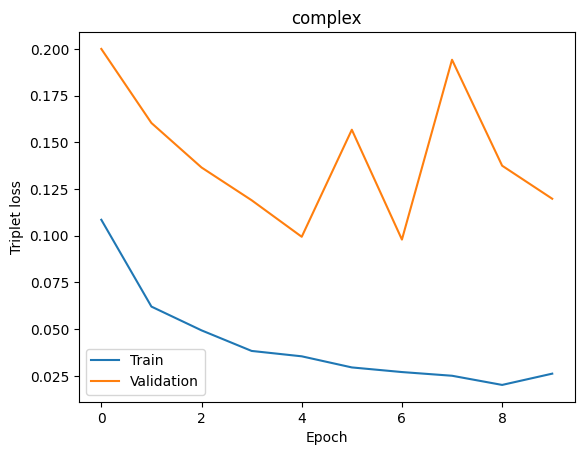

In [10]:
plot_history(history, NAME)